# Raw Close Matrix Profile Baseline

## Objective

This notebook establishes a univariate baseline for BTCUSDT 1-minute motif discovery using only the raw `close` price. It computes a STUMPY matrix profile with a 60-minute window, extracts the top non-overlapping motif pairs, and visualizes them through a matrix profile, highlighted raw-price windows, side-by-side candlesticks, and normalized overlays.

## 2. Imports

In [1]:
%matplotlib inline

from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import mplfinance as mpf
import numpy as np
import pandas as pd
import stumpy

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

## 3. Configuration

In [2]:
RUN_MODE = "month_test"  # Change to "full_year" for the complete 2025 slice.

ANALYSIS_YEAR = "2025"
TEST_MONTH = "2025-06"
WINDOW_SIZE = 60
TOP_K = 5
HIGHLIGHT_CONTEXT_MULTIPLIER = 4


def resolve_project_root(start=None):
    start = (Path.cwd() if start is None else Path(start)).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed" / "crypto" / "1min").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = resolve_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "crypto" / "1min" / "BTCUSDT_1m_processed.parquet"

if RUN_MODE not in {"month_test", "full_year"}:
    raise ValueError("RUN_MODE must be either 'month_test' or 'full_year'.")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"RUN_MODE: {RUN_MODE}")

Project root: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis
Data path: C:\Users\learn\OneDrive\Desktop\Masters Thesis\MastersThesis\data\processed\crypto\1min\BTCUSDT_1m_processed.parquet
RUN_MODE: month_test


## 4. Data Loading

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Processed BTC dataset was not found at: {DATA_PATH}")

load_columns = ["timestamp", "open", "high", "low", "close"]
df = pd.read_parquet(DATA_PATH, columns=load_columns)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").set_index("timestamp")
df_2025 = df.loc[ANALYSIS_YEAR].copy()

print(f"Loaded rows: {len(df):,}")
print(f"Rows in 2025: {len(df_2025):,}")
print(f"2025 date range: {df_2025.index.min()} -> {df_2025.index.max()}")

df_2025.head()

Loaded rows: 4,502,648
Rows in 2025: 525,600
2025 date range: 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:59:00+00:00


,open,high,low,close
timestamp,,,,
2025-01-01 00:00:00+00:00,93576.00,93610.93,93537.50,93610.93
2025-01-01 00:01:00+00:00,93610.93,93652.00,93606.20,93652.00
2025-01-01 00:02:00+00:00,93652.00,93702.15,93635.98,93702.15
2025-01-01 00:03:00+00:00,93702.14,93702.15,93654.48,93677.98
2025-01-01 00:04:00+00:00,93677.98,93677.99,93659.92,93661.20


## 5. Data Validation

In [4]:
required_columns = {"open", "high", "low", "close"}
missing_columns = required_columns.difference(df_2025.columns)

if missing_columns:
    raise KeyError(f"Missing required columns: {sorted(missing_columns)}")
if df_2025.empty:
    raise ValueError("The 2025 slice is empty.")
if not df_2025.index.is_monotonic_increasing:
    raise ValueError("The timestamp index must be sorted in ascending order.")
if df_2025.index.has_duplicates:
    raise ValueError("Duplicate timestamps were found in the 2025 slice.")

if RUN_MODE == "month_test":
    analysis_df = df_2025.loc[TEST_MONTH].copy()
    analysis_label = "June 2025"
else:
    analysis_df = df_2025.copy()
    analysis_label = "Full year 2025"

if analysis_df.empty:
    raise ValueError("The selected analysis slice is empty.")
if analysis_df["close"].isna().any():
    raise ValueError("The raw close series contains missing values.")

close = analysis_df["close"].astype(float).copy()
close_values = close.to_numpy(dtype=float)

if len(close_values) <= WINDOW_SIZE:
    raise ValueError("The selected series must be longer than the matrix profile window size.")

print(f"Analysis slice: {analysis_label}")
print(f"Rows analyzed: {len(analysis_df):,}")
print(f"Date range: {analysis_df.index.min()} -> {analysis_df.index.max()}")
print(f"Close summary: min={close.min():,.2f}, max={close.max():,.2f}, mean={close.mean():,.2f}")

analysis_df[["open", "high", "low", "close"]].head()

Analysis slice: June 2025
Rows analyzed: 43,200
Date range: 2025-06-01 00:00:00+00:00 -> 2025-06-30 23:59:00+00:00
Close summary: min=98,344.75, max=110,471.04, mean=105,680.47


,open,high,low,close
timestamp,,,,
2025-06-01 00:00:00+00:00,104591.88,104647.11,104591.88,104647.11
2025-06-01 00:01:00+00:00,104647.10,104647.11,104586.63,104600.77
2025-06-01 00:02:00+00:00,104600.77,104600.77,104537.73,104584.90
2025-06-01 00:03:00+00:00,104584.90,104605.60,104571.90,104571.90
2025-06-01 00:04:00+00:00,104571.91,104571.91,104530.42,104530.43


In [5]:
def _intervals_overlap(a_start, a_end, b_start, b_end):
    return max(a_start, b_start) < min(a_end, b_end)


def _zscore(values):
    values = np.asarray(values, dtype=float)
    std = values.std(ddof=0)
    if std == 0:
        return np.zeros_like(values)
    return (values - values.mean()) / std


def get_motif_pairs(profile, indices, m, k=5):
    profile = np.asarray(profile, dtype=float)
    indices = np.asarray(indices, dtype=int)

    motif_pairs = []
    occupied_intervals = []

    for idx in np.argsort(profile):
        profile_value = float(profile[idx])
        if not np.isfinite(profile_value):
            continue

        i = int(idx)
        j = int(indices[idx])
        if j < 0 or j >= len(profile) or i == j:
            continue

        i, j = sorted((i, j))
        if j < i + m:
            continue

        candidate_intervals = [(i, i + m), (j, j + m)]
        if any(
            _intervals_overlap(start, end, used_start, used_end)
            for start, end in candidate_intervals
            for used_start, used_end in occupied_intervals
        ):
            continue

        occupied_intervals.extend(candidate_intervals)
        motif_pairs.append(
            {
                "i": i,
                "j": j,
                "m": int(m),
                "profile_value": profile_value,
            }
        )

        if len(motif_pairs) == k:
            break

    return motif_pairs


def plot_matrix_profile(profile, motif_indices):
    profile = np.asarray(profile, dtype=float)
    x = np.arange(len(profile))

    fig, ax = plt.subplots(figsize=(14, 4.2))
    ax.plot(x, profile, color="#1d3557", linewidth=1.0, label="Matrix profile")

    if motif_indices:
        motif_indices = np.asarray(motif_indices, dtype=int)
        ax.scatter(
            motif_indices,
            profile[motif_indices],
            color="#2a9d8f",
            s=42,
            zorder=3,
            label="Selected motifs",
        )

    ax.set_title("Matrix profile over raw close subsequences")
    ax.set_xlabel("Subsequence start index")
    ax.set_ylabel("Profile value")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_motif_windows(df, i, j, m):
    context = HIGHLIGHT_CONTEXT_MULTIPLIER * m
    start = max(0, min(i, j) - context)
    end = min(len(df), max(i, j) + m + context)
    subset = df.iloc[start:end]

    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.plot(subset.index, subset["close"], color="#1d3557", linewidth=1.2, label="Close")
    ax.axvspan(df.index[i], df.index[i + m - 1], color="#2a9d8f", alpha=0.25, label=f"Motif A ({i}:{i + m})")
    ax.axvspan(df.index[j], df.index[j + m - 1], color="#f4a261", alpha=0.25, label=f"Motif B ({j}:{j + m})")
    ax.set_title("Raw close price with highlighted motif windows")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Close price")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_candles_side_by_side(df, i, j, m):
    ohlc_columns = ["open", "high", "low", "close"]
    left = df.iloc[i:i + m][ohlc_columns].rename(columns=str.title)
    right = df.iloc[j:j + m][ohlc_columns].rename(columns=str.title)

    market_colors = mpf.make_marketcolors(
        up="#2a9d8f",
        down="#e76f51",
        wick="inherit",
        edge="inherit",
    )
    style = mpf.make_mpf_style(
        base_mpl_style="seaborn-v0_8-whitegrid",
        marketcolors=market_colors,
        gridstyle=":",
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharey=True)
    plot_kwargs = {
        "type": "candle",
        "style": style,
        "volume": False,
        "show_nontrading": False,
        "xrotation": 0,
    }

    mpf.plot(left, ax=axes[0], **plot_kwargs)
    mpf.plot(right, ax=axes[1], **plot_kwargs)

    y_min = min(left["Low"].min(), right["Low"].min())
    y_max = max(left["High"].max(), right["High"].max())
    for ax in axes:
        ax.set_ylim(y_min, y_max)
        ax.set_ylabel("Price")
        ax.grid(alpha=0.3)

    axes[0].set_title(f"Motif A | {left.index[0]:%Y-%m-%d %H:%M} to {left.index[-1]:%Y-%m-%d %H:%M}")
    axes[1].set_title(f"Motif B | {right.index[0]:%Y-%m-%d %H:%M} to {right.index[-1]:%Y-%m-%d %H:%M}")
    fig.suptitle("Side-by-side candlestick comparison", y=1.02)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()
    return fig, axes


def plot_normalized_overlay(close, i, j, m):
    first_window = close.iloc[i:i + m]
    second_window = close.iloc[j:j + m]
    first_norm = _zscore(first_window.to_numpy(dtype=float))
    second_norm = _zscore(second_window.to_numpy(dtype=float))

    fig, ax = plt.subplots(figsize=(10, 4.2))
    ax.plot(first_norm, color="#2a9d8f", linewidth=2.0, label=f"Motif A | {first_window.index[0]:%Y-%m-%d %H:%M}")
    ax.plot(second_norm, color="#f4a261", linewidth=2.0, linestyle="--", label=f"Motif B | {second_window.index[0]:%Y-%m-%d %H:%M}")
    ax.axhline(0.0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_title("Normalized overlay of raw close windows")
    ax.set_xlabel("Minute within the 60-minute window")
    ax.set_ylabel("Z-score")
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()
    return fig, ax

## 6. Matrix Profile Computation (Univariate Close)

In [6]:
# The matrix profile input is the raw close price only.
start_time = perf_counter()
mp = stumpy.stump(close_values, WINDOW_SIZE)
elapsed_seconds = perf_counter() - start_time

profile = mp[:, 0]
indices = mp[:, 1]

profile = np.asarray(profile, dtype=float)
indices = np.asarray(indices, dtype=int)
valid_profile = profile[np.isfinite(profile)]

print(f"Matrix profile computed in {elapsed_seconds:.2f} seconds")
print(f"Profile length: {len(profile):,}")
print(f"Valid profile values: {len(valid_profile):,}")

pd.Series(valid_profile).describe()

Matrix profile computed in 23.86 seconds
Profile length: 43,141
Valid profile values: 43,141


count    43141.000000
mean         3.336511
std          1.038209
min          1.174133
25%          2.542817
50%          3.221148
75%          4.035824
max          7.565793
dtype: float64

## 7. Motif Extraction

In [7]:
motif_pairs = get_motif_pairs(profile, indices, WINDOW_SIZE, k=TOP_K)

if not motif_pairs:
    raise ValueError("No valid non-overlapping motif pairs were found.")
if len(motif_pairs) < TOP_K:
    print(f"Only {len(motif_pairs)} non-overlapping motif pairs were found.")

motif_pairs_df = pd.DataFrame(
    [
        {
            "rank": rank,
            "i": pair["i"],
            "j": pair["j"],
            "m": pair["m"],
            "profile_value": pair["profile_value"],
            "i_start": analysis_df.index[pair["i"]],
            "i_end": analysis_df.index[pair["i"] + pair["m"] - 1],
            "j_start": analysis_df.index[pair["j"]],
            "j_end": analysis_df.index[pair["j"] + pair["m"] - 1],
        }
        for rank, pair in enumerate(motif_pairs, start=1)
    ]
)
motif_indices = [pair["i"] for pair in motif_pairs]

motif_pairs_df

,rank,i,j,m,profile_value,i_start,i_end,j_start,j_end
0,1,22217,39660,60,1.174133,2025-06-16 10:17:00+00:00,2025-06-16 11:16:00+00:00,2025-06-28 13:00:00+00:00,2025-06-28 13:59:00+00:00
1,2,18151,27809,60,1.216164,2025-06-13 14:31:00+00:00,2025-06-13 15:30:00+00:00,2025-06-20 07:29:00+00:00,2025-06-20 08:28:00+00:00
2,3,6556,42128,60,1.255637,2025-06-05 13:16:00+00:00,2025-06-05 14:15:00+00:00,2025-06-30 06:08:00+00:00,2025-06-30 07:07:00+00:00
3,4,20460,31997,60,1.329038,2025-06-15 05:00:00+00:00,2025-06-15 05:59:00+00:00,2025-06-23 05:17:00+00:00,2025-06-23 06:16:00+00:00
4,5,25684,32689,60,1.355743,2025-06-18 20:04:00+00:00,2025-06-18 21:03:00+00:00,2025-06-23 16:49:00+00:00,2025-06-23 17:48:00+00:00


## 8. Visualization

### Matrix profile plot

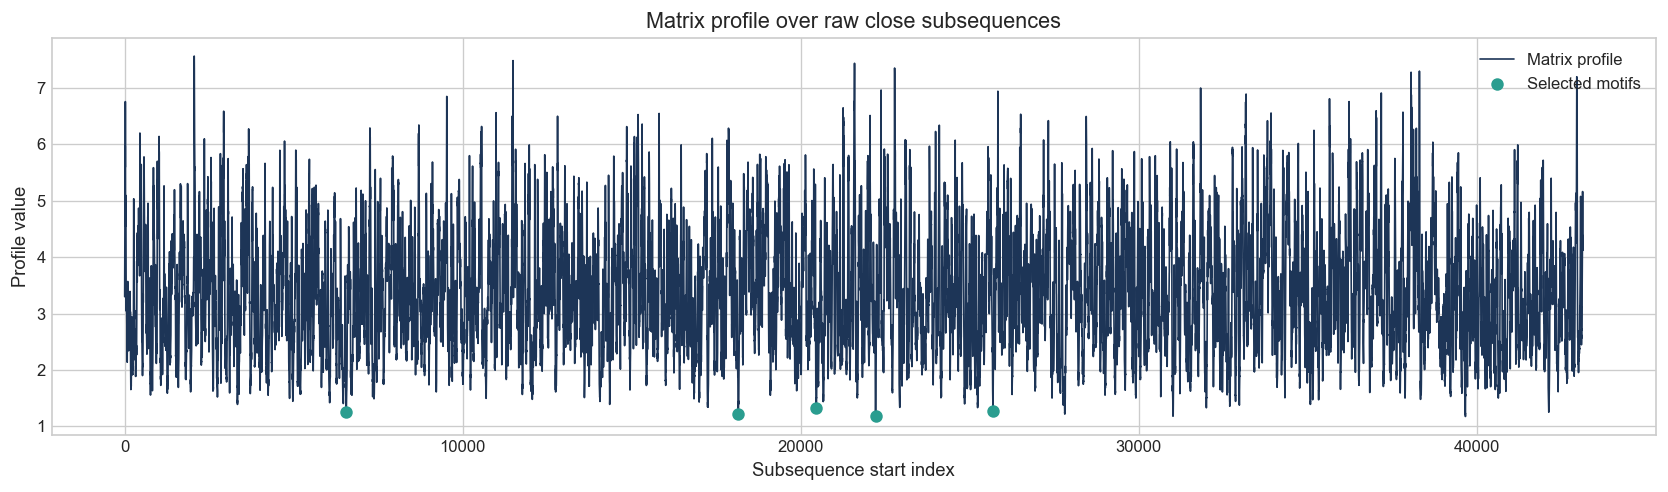

(<Figure size 1680x504 with 1 Axes>,
 <Axes: title={'center': 'Matrix profile over raw close subsequences'}, xlabel='Subsequence start index', ylabel='Profile value'>)

In [8]:
plot_matrix_profile(profile, motif_indices)

### Raw close series with motif highlights

Motif 1: i=22217, j=39660, profile=1.1741


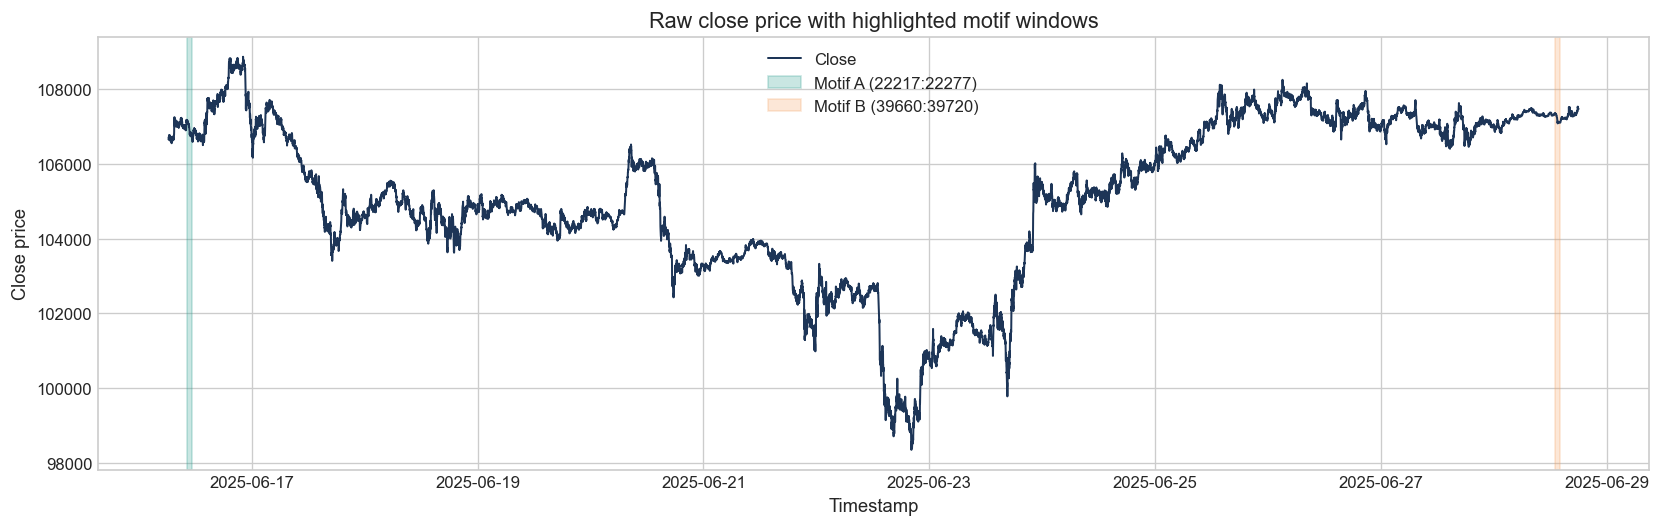

Motif 2: i=18151, j=27809, profile=1.2162


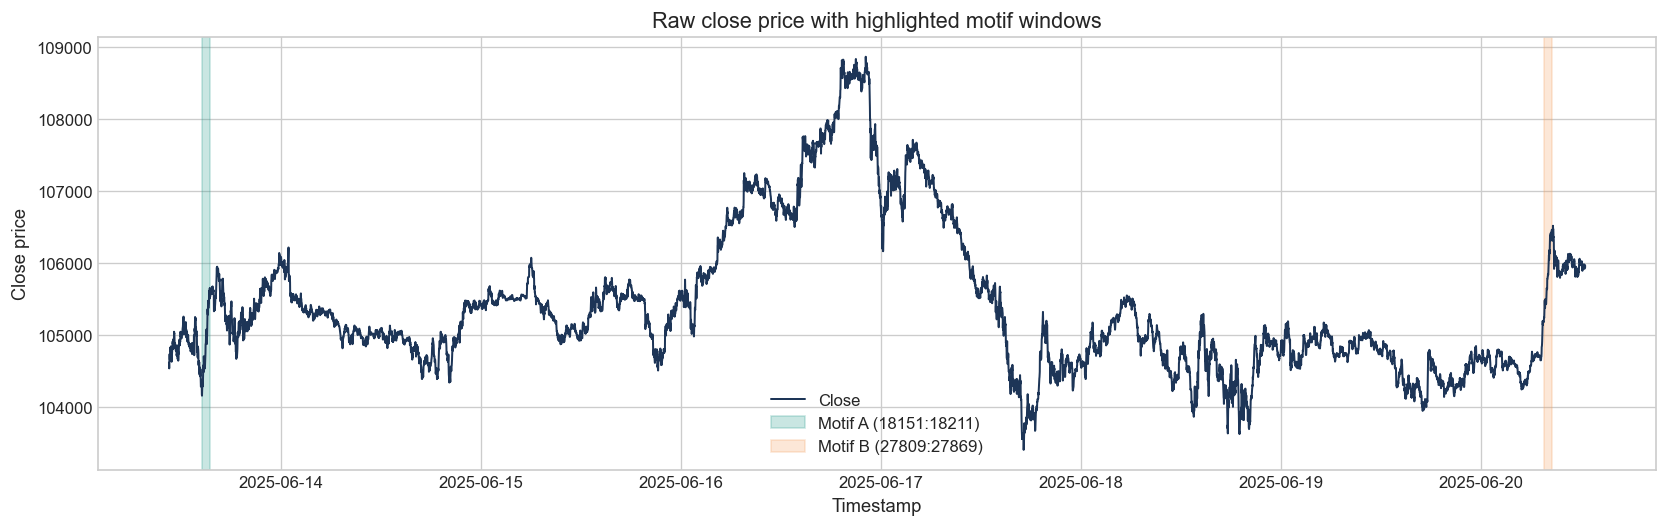

Motif 3: i=6556, j=42128, profile=1.2556


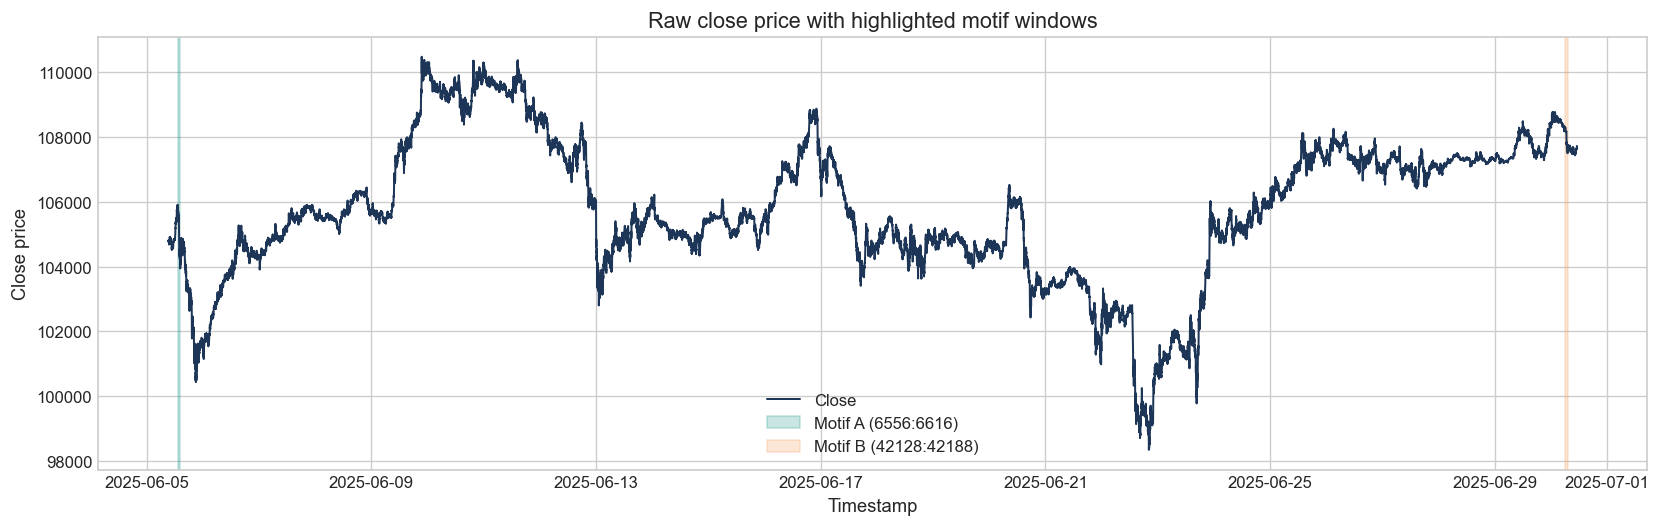

Motif 4: i=20460, j=31997, profile=1.3290


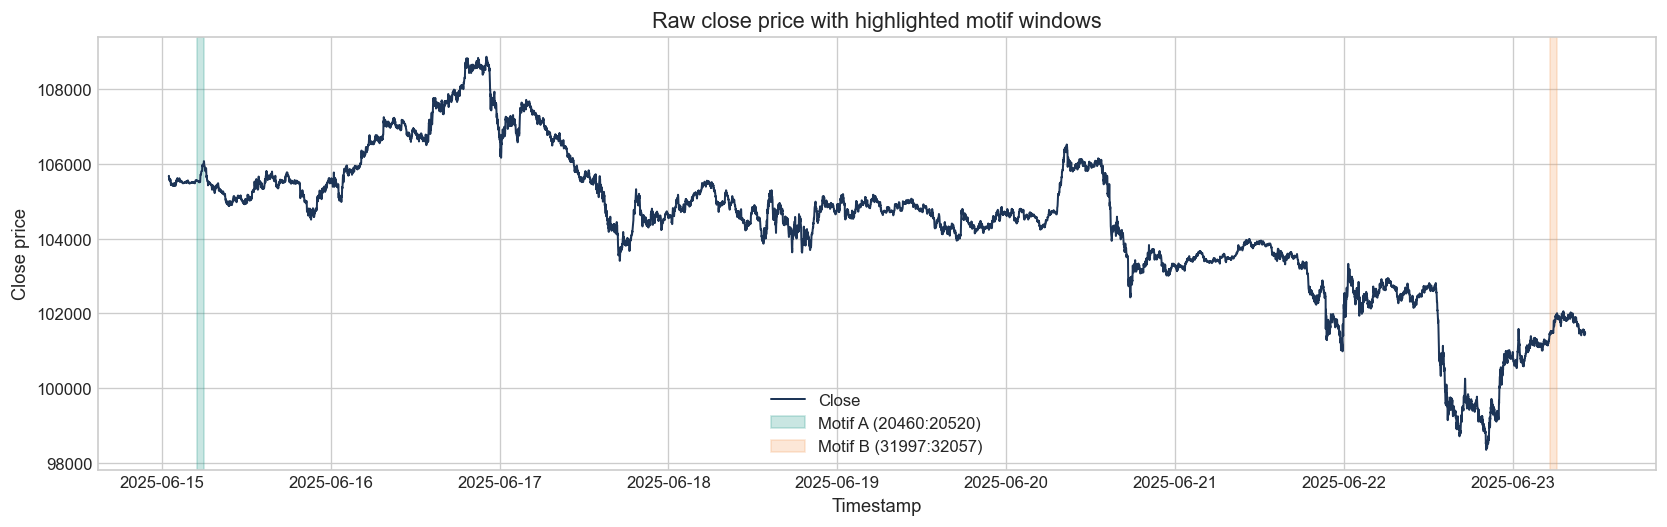

Motif 5: i=25684, j=32689, profile=1.3557


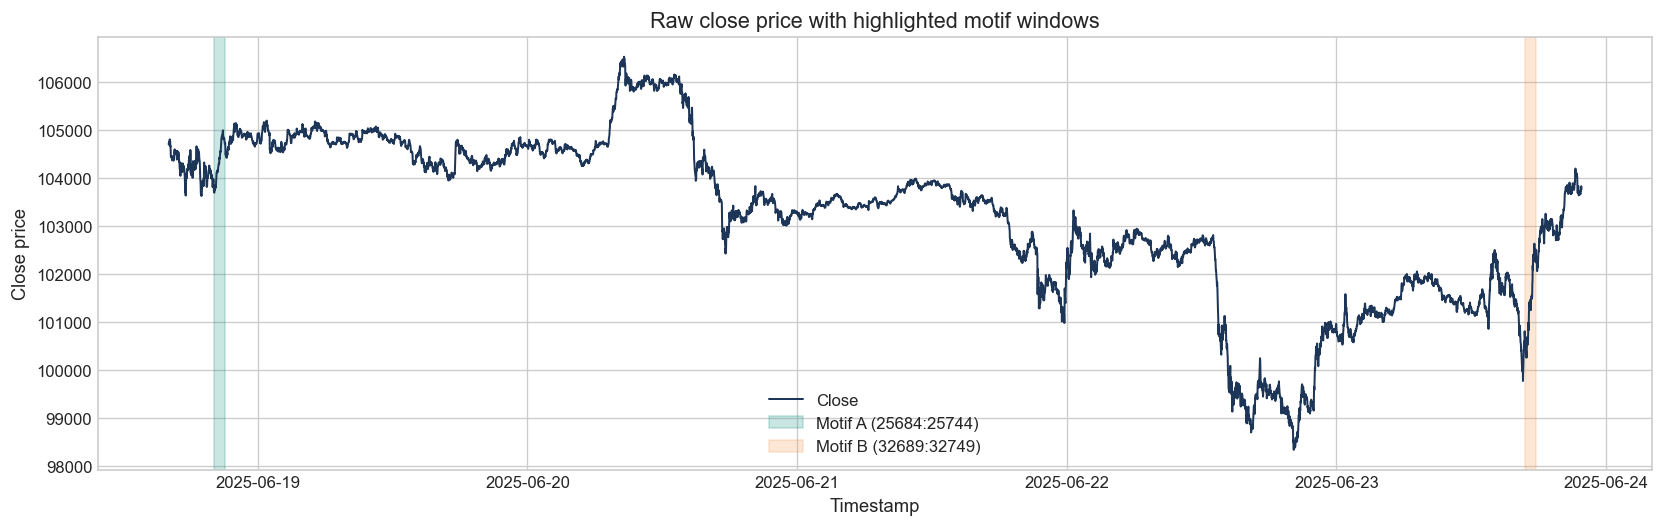

In [9]:
for rank, pair in enumerate(motif_pairs, start=1):
    print(
        f"Motif {rank}: i={pair['i']}, j={pair['j']}, "
        f"profile={pair['profile_value']:.4f}"
    )
    plot_motif_windows(analysis_df, pair["i"], pair["j"], pair["m"])

### Candlestick comparison (SIDE-BY-SIDE)

Candlestick comparison for motif 1


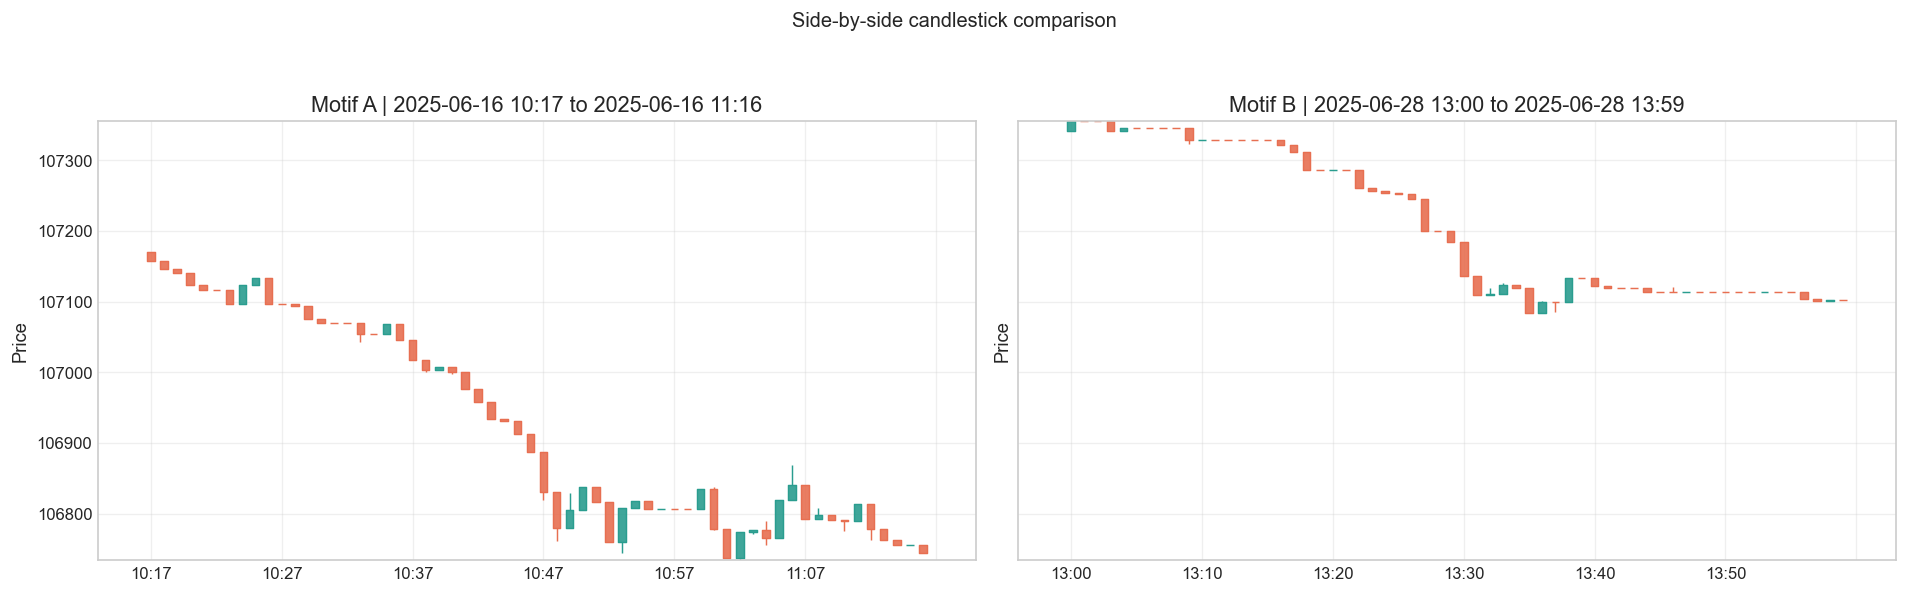

Candlestick comparison for motif 2


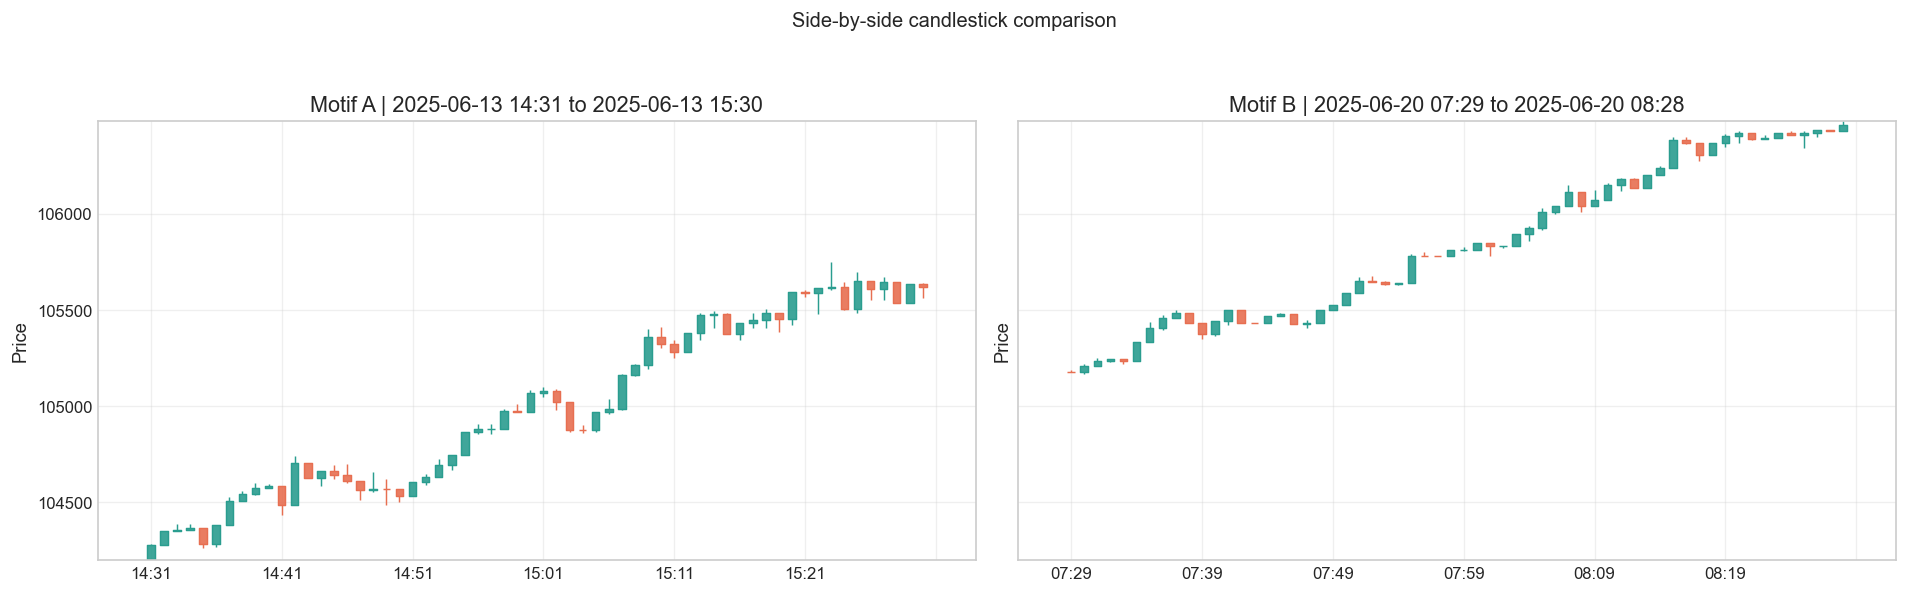

Candlestick comparison for motif 3


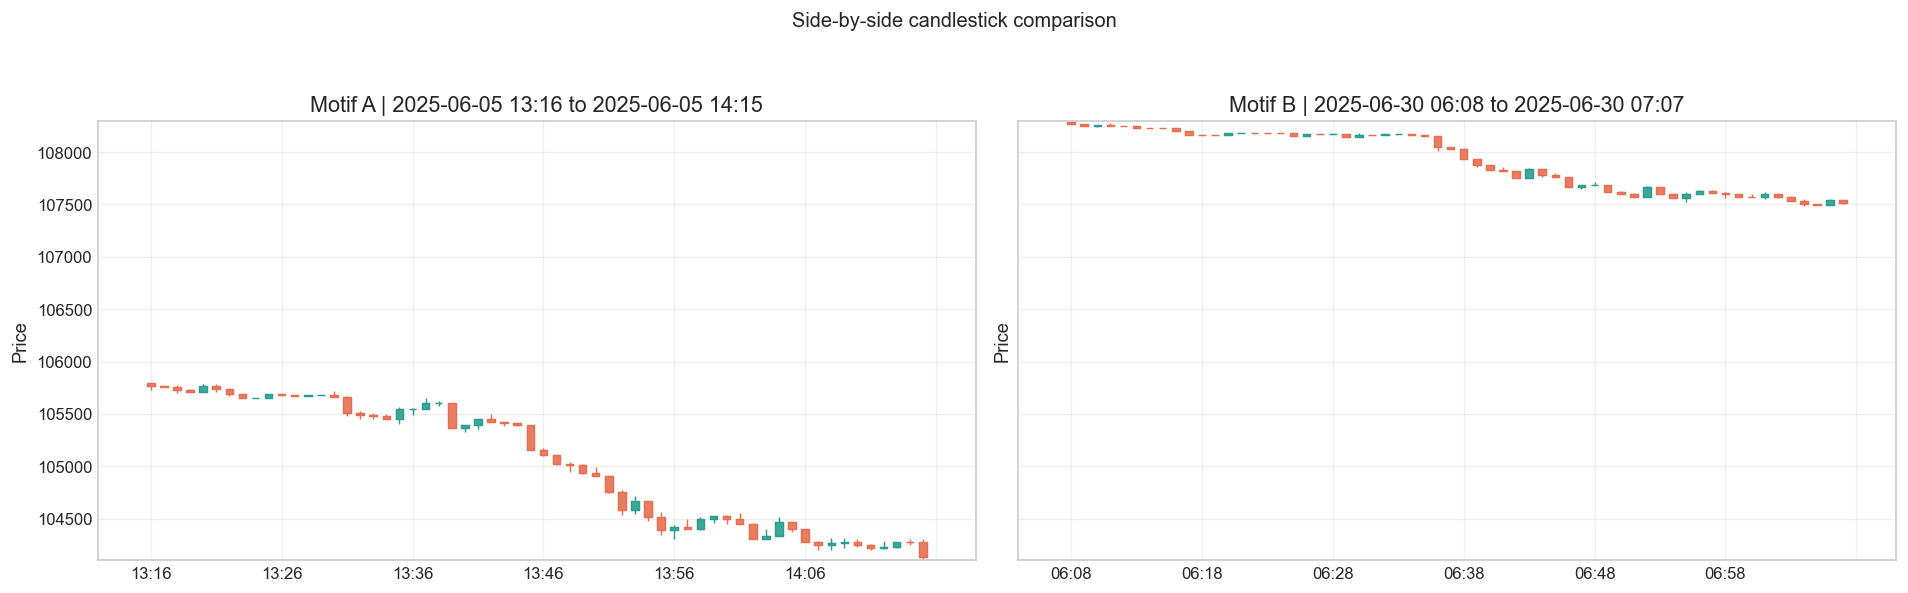

Candlestick comparison for motif 4


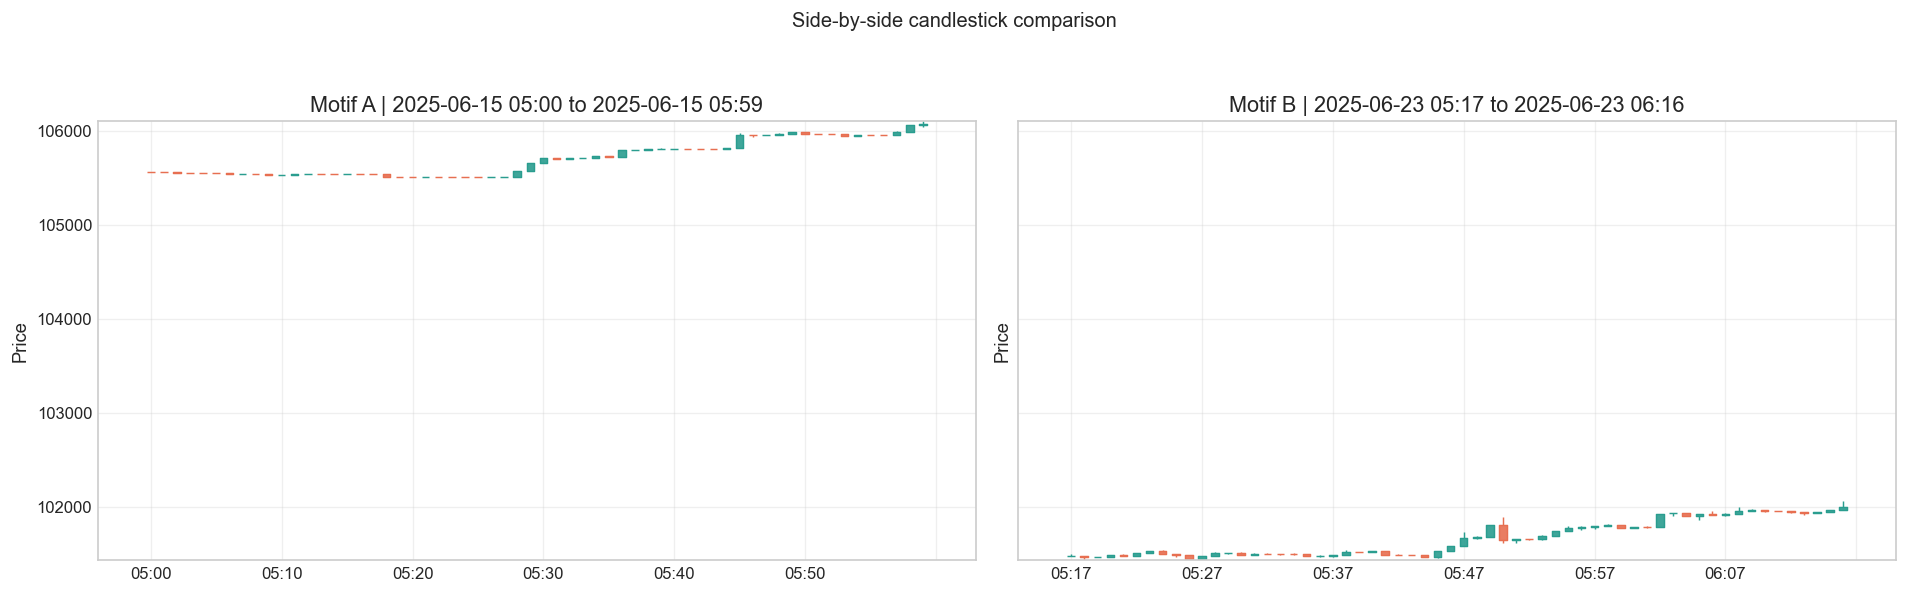

Candlestick comparison for motif 5


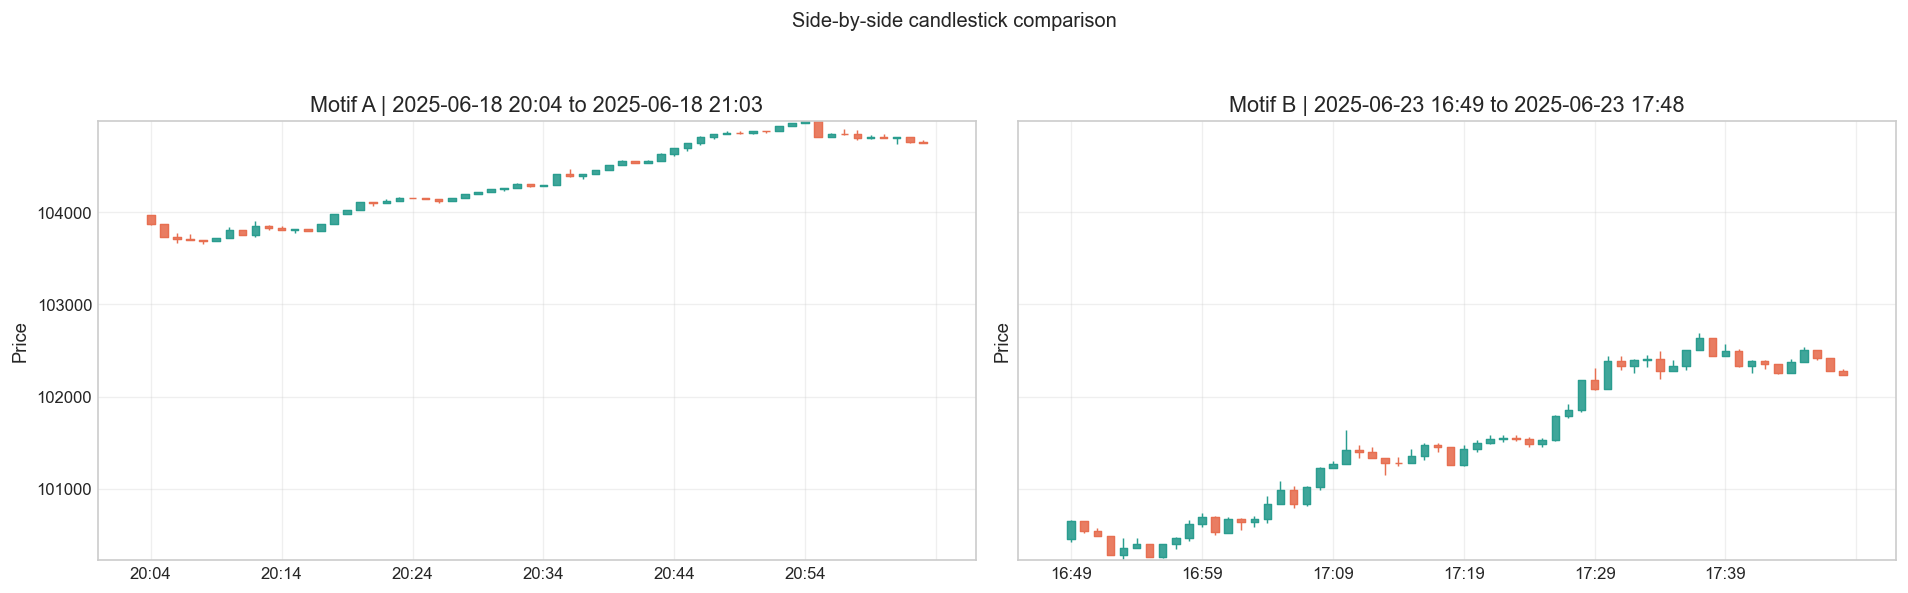

In [10]:
for rank, pair in enumerate(motif_pairs, start=1):
    print(f"Candlestick comparison for motif {rank}")
    plot_candles_side_by_side(analysis_df, pair["i"], pair["j"], pair["m"])

### Normalized overlay of motif windows

Normalized overlay for motif 1


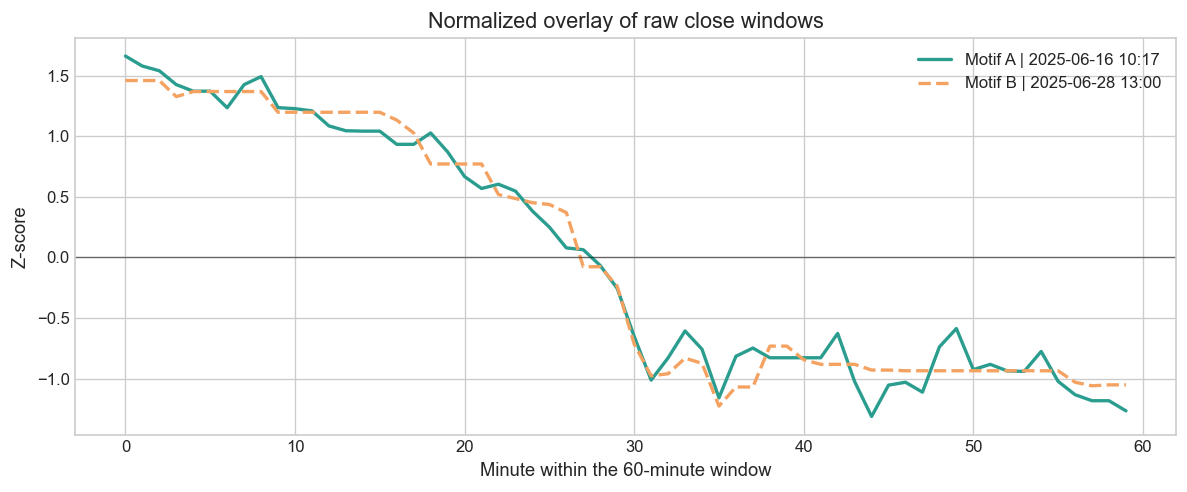

Normalized overlay for motif 2


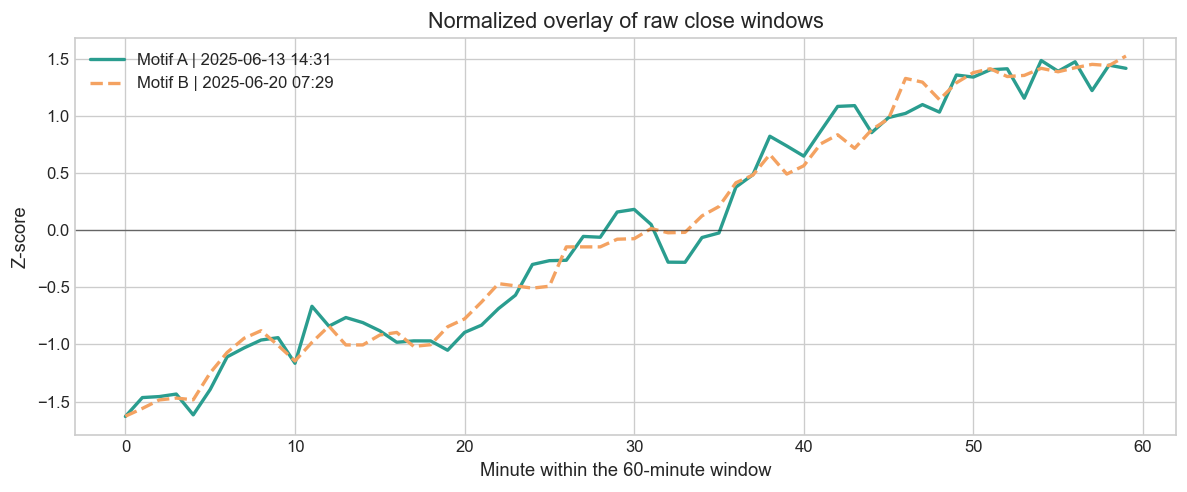

Normalized overlay for motif 3


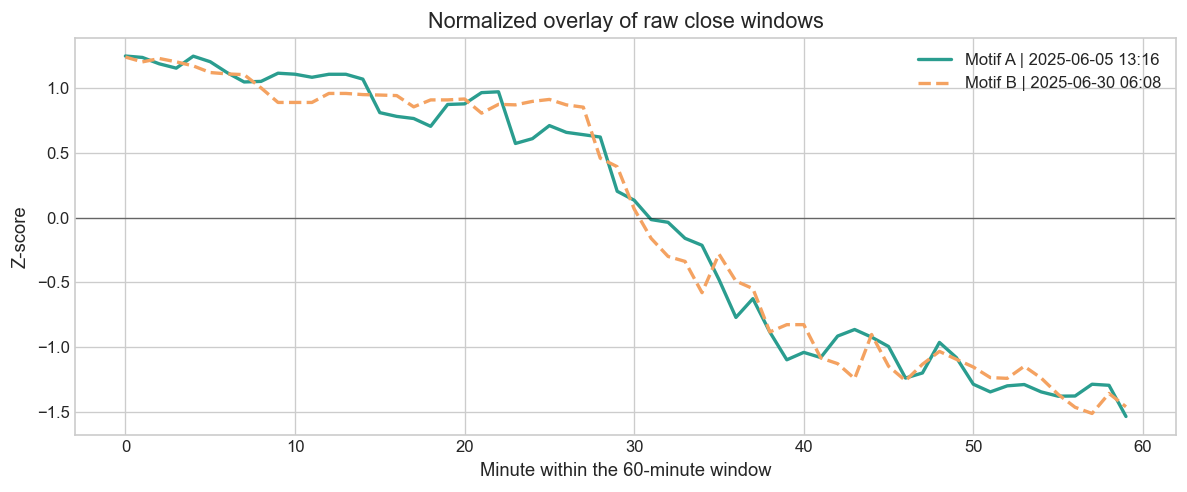

Normalized overlay for motif 4


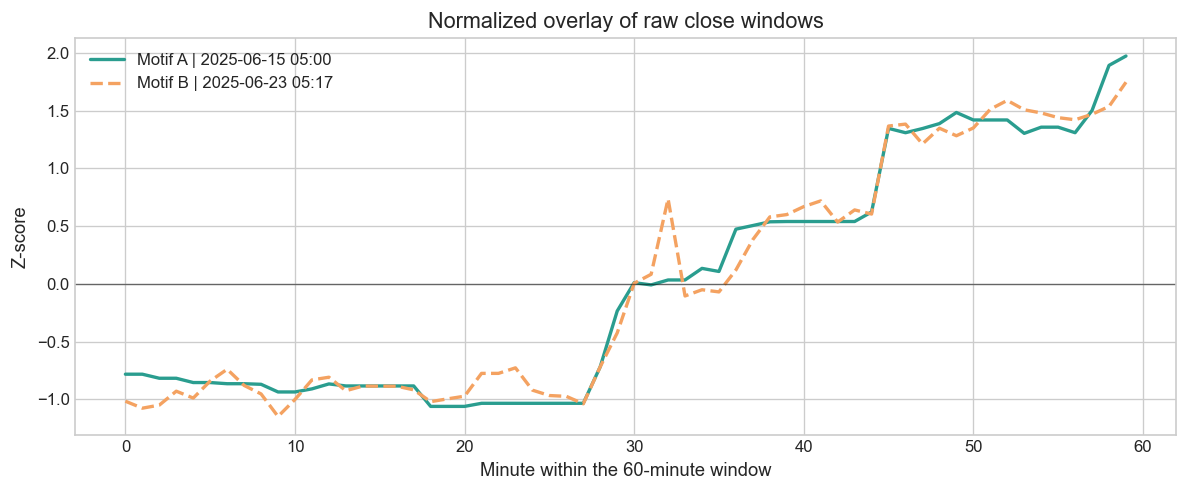

Normalized overlay for motif 5


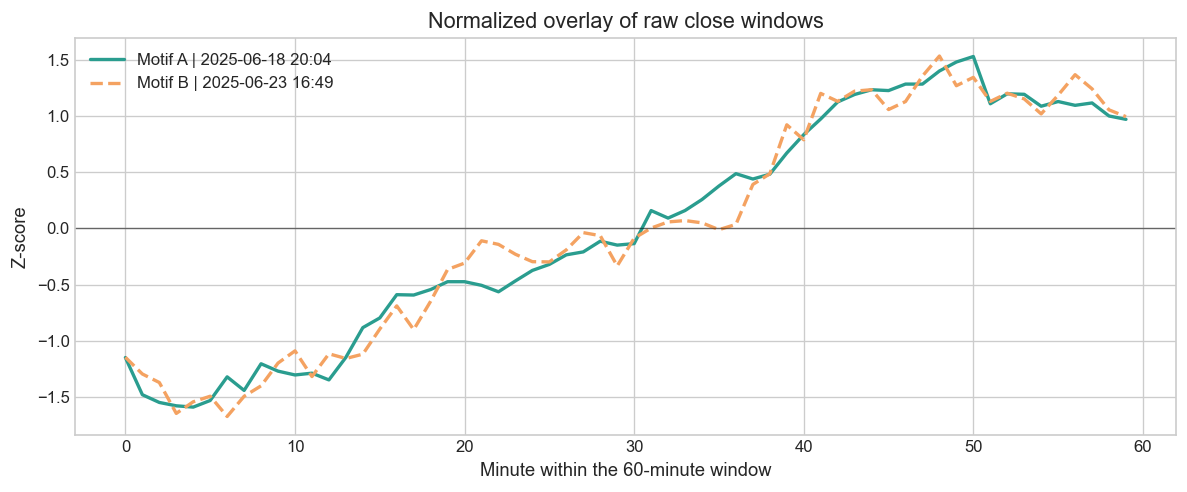

In [11]:
for rank, pair in enumerate(motif_pairs, start=1):
    print(f"Normalized overlay for motif {rank}")
    plot_normalized_overlay(close, pair["i"], pair["j"], pair["m"])

## 9. Summary

This notebook provides a raw-price baseline only. The motif search uses the univariate `close` series directly, while the normalized overlays are limited to visualization so that matched shapes can be compared on a common scale.

In [12]:
matrix_profile_stats = pd.Series(valid_profile).describe()[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]

print("Raw close motif discovery summary")
print(f"- RUN_MODE: {RUN_MODE}")
print(f"- Analysis slice: {analysis_label}")
print(f"- Number of motifs found: {len(motif_pairs)}")
print(f"- Window size: {WINDOW_SIZE}")
print(f"- Data length: {len(close_values):,}")
print("- Basic stats of matrix profile:")
print(matrix_profile_stats.to_string(float_format=lambda value: f"{value:,.4f}"))

Raw close motif discovery summary
- RUN_MODE: month_test
- Analysis slice: June 2025
- Number of motifs found: 5
- Window size: 60
- Data length: 43,200
- Basic stats of matrix profile:
count   43,141.0000
mean         3.3365
std          1.0382
min          1.1741
25%          2.5428
50%          3.2211
75%          4.0358
max          7.5658
